# 1D PDE Collocation Points And Data Grid

This notebook visualises both the 1D PDE collocation points used by the BINN PDE loss and the fixed `38 x 5` data grid used for the measurements. The PDE sampling is taken directly from `Training/binn/python/Modules/Models/BuildBINNs.py`, so the plot uses the same `(x, t)` ordering, bounds, and `loss_count` seeding strategy as training.

The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462).


In [10]:
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import BoundaryNorm

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals
from Training.JN.notebook_helpers.notebook_data import load_original_data

PATHS = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = PATHS.project_root
TRAINING_ROOT = PATHS.training_root
JN_ROOT = PATHS.notebook_root
OUTPUT_DIR = JN_ROOT / "pngs" / "colocation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

register_notebook_pickle_globals()

from Training.binn.python.Modules.Models.BuildBINNs import generate_random_inputs

print(f"Saving plots to: {OUTPUT_DIR}")


Saving plots to: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/colocation


In [11]:
data_orig_obj_FKPP = load_original_data(PATHS.data_root)
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t

x_min, x_max = float(np.min(x)), float(np.max(x))
t_min, t_max = float(np.min(t)), float(np.max(t))
dx = (x_max - x_min) / max(len(x) - 1, 1)
dt = (t_max - t_min) / max(len(t) - 1, 1)

print(f"x-domain: [{x_min:.6f}, {x_max:.6f}]")
print(f"t-domain: [{t_min:.6f}, {t_max:.6f}]")
print(f"space grid points: {len(x)}")
print(f"time grid points: {len(t)}")
print(f"data grid size: {len(x)} x {len(t)} = {len(x) * len(t)} points")



x-domain: [0.025000, 1.875000]
t-domain: [0.000000, 2.000000]
space grid points: 38
time grid points: 5
data grid size: 38 x 5 = 190 points


In [12]:
def sample_pde_collocation_points_1d(num_samples=100, loss_count=0, device="cpu"):
    sampler = SimpleNamespace(
        dim=1,
        num_samples=num_samples,
        loss_count=loss_count,
        x1_min=x_min,
        x1_max=x_max,
        t_min=t_min,
        t_max=t_max,
    )
    reference_inputs = torch.empty((1, 2), device=device)
    return generate_random_inputs(sampler, reference_inputs).detach().cpu().numpy()


def sample_repeated_pde_collocation_points_1d(num_samples=100, reps=10, device="cpu"):
    return [
        sample_pde_collocation_points_1d(
            num_samples=num_samples,
            loss_count=loss_count,
            device=device,
        )
        for loss_count in range(reps)
    ]


def build_data_grid_points_1d(x_values, t_values):
    x_mesh, t_mesh = np.meshgrid(x_values, t_values, indexing="xy")
    return np.column_stack([x_mesh.ravel(), t_mesh.ravel()])


def axis_limits(x_padding=None, t_padding=None):
    if x_padding is None:
        x_padding = 0.5 * dx
    if t_padding is None:
        t_padding = 0.5 * dt
    return (
        x_min - x_padding,
        x_max + x_padding,
        t_min - t_padding,
        t_max + t_padding,
    )


def save_current_figure(filename):
    output_path = OUTPUT_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved {output_path}")


def plot_point_cloud(
    points,
    filename,
    marker_size=20,
    alpha=0.85,
    x_padding=None,
    t_padding=None,
    axis_label_fontsize=20,
    axis_tick_fontsize=20,
    c=None
):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    if c is None:
        ax.scatter(points[:, 0], points[:, 1], s=marker_size, alpha=alpha, c=c)
    else:
        ax.scatter(points[:, 0], points[:, 1], s=marker_size, alpha=alpha, c=c)
    ax.set_xlabel("x [mm]", fontsize=axis_label_fontsize)
    ax.set_ylabel("t [days]", fontsize=axis_label_fontsize)
    ax.tick_params(axis="both", labelsize=axis_tick_fontsize)
    x_lo, x_hi, t_lo, t_hi = axis_limits(x_padding=x_padding, t_padding=t_padding)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(t_lo, t_hi)
    save_current_figure(filename)
    plt.show()


def plot_repeated_point_clouds(
    point_sets,
    filename,
    marker_size=18,
    x_padding=None,
    t_padding=None,
    axis_label_fontsize=20,
    axis_tick_fontsize=20,
):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for rep, points in enumerate(point_sets, start=1):
        alpha = rep / len(point_sets)
        ax.scatter(points[:, 0], points[:, 1], s=marker_size, alpha=alpha)
    ax.set_xlabel("x [mm]", fontsize=axis_label_fontsize)
    ax.set_ylabel("t [days]", fontsize=axis_label_fontsize)
    ax.tick_params(axis="both", labelsize=axis_tick_fontsize)
    x_lo, x_hi, t_lo, t_hi = axis_limits(x_padding=x_padding, t_padding=t_padding)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(t_lo, t_hi)
    save_current_figure(filename)
    plt.show()


def plot_point_density(
    point_sets,
    filename,
    dx,
    dt,
    marker_size=20,
    n_levels=8,
    colorbar_label="density",
    axis_label_fontsize=15,
    axis_tick_fontsize=15,
):
    all_points = np.vstack(point_sets)
    x_edges = np.arange(x_min, x_max + dx, dx)
    t_edges = np.arange(t_min, t_max + dt, dt)

    counts, x_edges, t_edges = np.histogram2d(
        all_points[:, 0],
        all_points[:, 1],
        bins=[x_edges, t_edges],
    )
    density = counts / (dx * dt)

    vmin = float(density.min())
    vmax = float(density.max())
    if vmax == vmin:
        levels = np.linspace(vmin, vmax + 1.0, n_levels + 1)
    else:
        levels = np.linspace(vmin, vmax, n_levels + 1)

    cmap = plt.get_cmap("viridis", n_levels)
    norm = BoundaryNorm(levels, ncolors=cmap.N)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    mesh = ax.pcolormesh(
        x_edges,
        t_edges,
        density.T,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )
    cbar = fig.colorbar(
        mesh,
        ax=ax,
        boundaries=levels,
        ticks=levels,
        spacing="proportional",
    )
    cbar.set_label(colorbar_label, fontsize=axis_label_fontsize)
    cbar.ax.tick_params(labelsize=axis_tick_fontsize)

    ax.set_xlabel("x [mm]", fontsize=axis_label_fontsize)
    ax.set_ylabel("t [days]", fontsize=axis_label_fontsize)
    ax.tick_params(axis="both", labelsize=axis_tick_fontsize)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(t_min, t_max)
    save_current_figure(filename)
    plt.show()


## PDE collocation points

Saved /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/colocation/pde_single_draw_1000.png


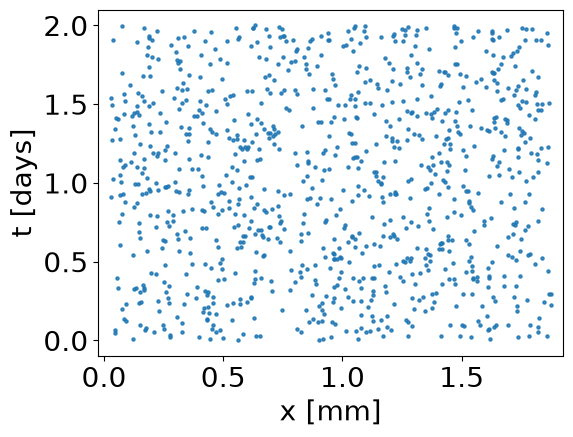

Saved /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/colocation/pde_repeated_draws_1000_10.png


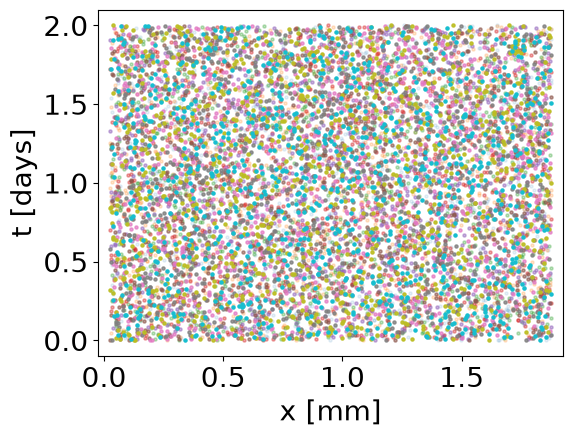

In [13]:
num_pde_samples = 1000
repetitions = 10

single_pde_draw = sample_pde_collocation_points_1d(
    num_samples=num_pde_samples,
    loss_count=10,

)
repeated_pde_draws = sample_repeated_pde_collocation_points_1d(
    num_samples=num_pde_samples,
    reps=repetitions,
)

plot_point_cloud(
    single_pde_draw,
    filename=f"pde_single_draw_{num_pde_samples}.png",
     marker_size=5,
    x_padding=1 * dx,
    t_padding=0.2 * dt,
     
)
plot_repeated_point_clouds(
    repeated_pde_draws,
    filename=f"pde_repeated_draws_{num_pde_samples}_{repetitions}.png",
    marker_size=5,
    x_padding=1 * dx,
    t_padding=0.2 * dt,
)


## Data points

Total data points: 190
Saved /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/colocation/data_grid_points.png


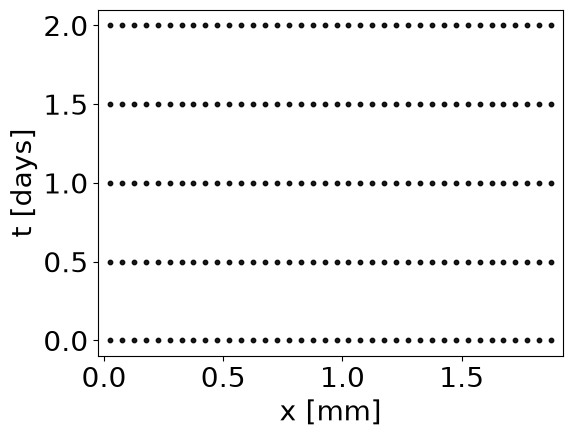

In [14]:
data_grid_points = build_data_grid_points_1d(x, t)
print(f"Total data points: {len(data_grid_points)}")

plot_point_cloud(
    data_grid_points,
    filename="data_grid_points.png",
    marker_size=10,
    alpha=0.9,
    x_padding=1 * dx,
    t_padding=0.2 * dt,
    c='k'
)


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
